# Final Model Comparison & Analysis

Comprehensive comparison of all models (classical ML and deep learning)
on the NASA PCoE dataset. Includes aggregate metrics, error analysis by
degradation phase, interpretability, and deployability assessment.

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd()
if not (PROJECT_ROOT / 'config').exists():
    PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'config').exists():
    PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.evaluation.comparison import build_comparison_table, rank_models
from src.evaluation.error_analysis import phase_rmse, phase_summary_table
from src.evaluation.validation import cell_based_loocv, scale_features

sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
with open("config/default.yaml") as f:
    config = yaml.safe_load(f)

Project root: /Users/malakmekyassi/Documents/GitHub/soh_estimation


## 1. Load All Results

In [2]:
with open("experiments/classical_results.yaml") as f:
    classical_results = yaml.safe_load(f)

with open("experiments/dl_results.yaml") as f:
    dl_results = yaml.safe_load(f)

all_results = {**classical_results, **dl_results}
print("All models:", list(all_results.keys()))

All models: ['gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']


## 2. Aggregate Metrics Comparison

In [3]:
comp_table = build_comparison_table(all_results)
print(comp_table[["Model", "RMSE", "MAE", "MAXAE", "R2"]].to_string(index=False))

      Model                RMSE                 MAE               MAXAE                   R2
        gpr 0.029786 ± 0.018711 0.027226 ± 0.019333 0.097737 ± 0.019520  0.885342 ± 0.096640
      naive 0.112007 ± 0.026619 0.096459 ± 0.024578 0.202872 ± 0.046925 -0.285350 ± 0.249911
         rf 0.025054 ± 0.016882 0.019642 ± 0.014220 0.083830 ± 0.035908  0.926623 ± 0.072572
        svr 0.015025 ± 0.005611 0.010623 ± 0.003781 0.054004 ± 0.016540  0.972900 ± 0.019861
        cnn 0.103986 ± 0.059456 0.085159 ± 0.043883 0.226713 ± 0.143872 -2.504108 ± 3.070670
       lstm 0.047648 ± 0.019657 0.043205 ± 0.019059 0.098025 ± 0.034097 -0.134789 ± 1.366300
transformer 0.067324 ± 0.022113 0.059304 ± 0.021343 0.138776 ± 0.040154 -0.142490 ± 0.513330


## 3. Model Ranking by RMSE

In [4]:
ranking = rank_models(all_results, primary_metric="rmse_mean")
print(ranking.to_string(index=False))

 Rank       Model  rmse_mean
    1         svr   0.015025
    2          rf   0.025054
    3         gpr   0.029786
    4        lstm   0.047648
    5 transformer   0.067324
    6         cnn   0.103986
    7       naive   0.112007


## 4. Metric Comparisons

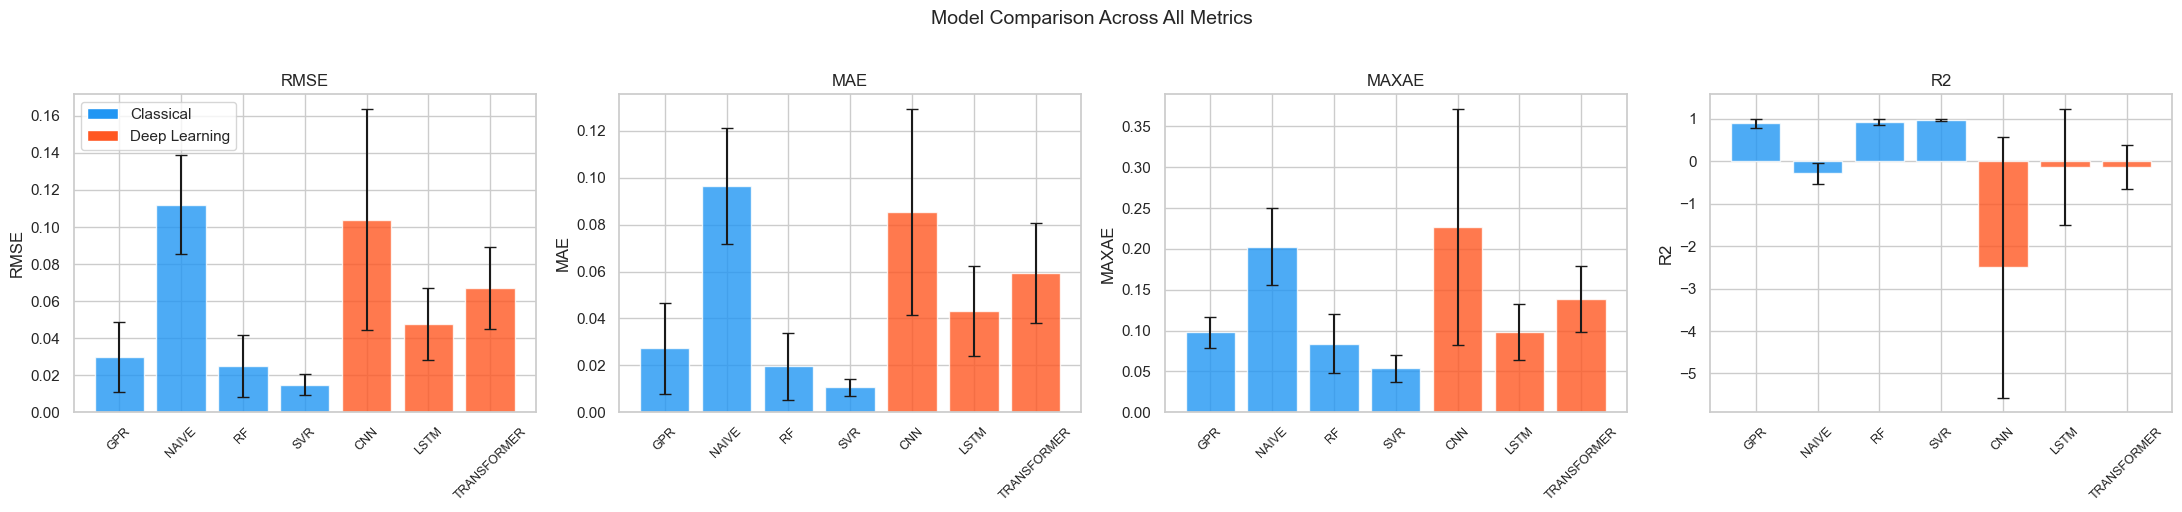

In [5]:
dl_models = ["lstm", "cnn", "transformer"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric in zip(axes, ["rmse", "mae", "maxae", "r2"]):
    models = list(all_results.keys())
    means = [all_results[m].get(f"{metric}_mean", 0) for m in models]
    stds = [all_results[m].get(f"{metric}_std", 0) for m in models]
    x = np.arange(len(models))
    colors = ["#FF5722" if m in dl_models else "#2196F3" for m in models]
    ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in models], rotation=45, fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2196F3", label="Classical"),
                   Patch(facecolor="#FF5722", label="Deep Learning")]
axes[0].legend(handles=legend_elements, loc="upper left")
fig.suptitle("Model Comparison Across All Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. SOH Trajectory Predictions (SVR)

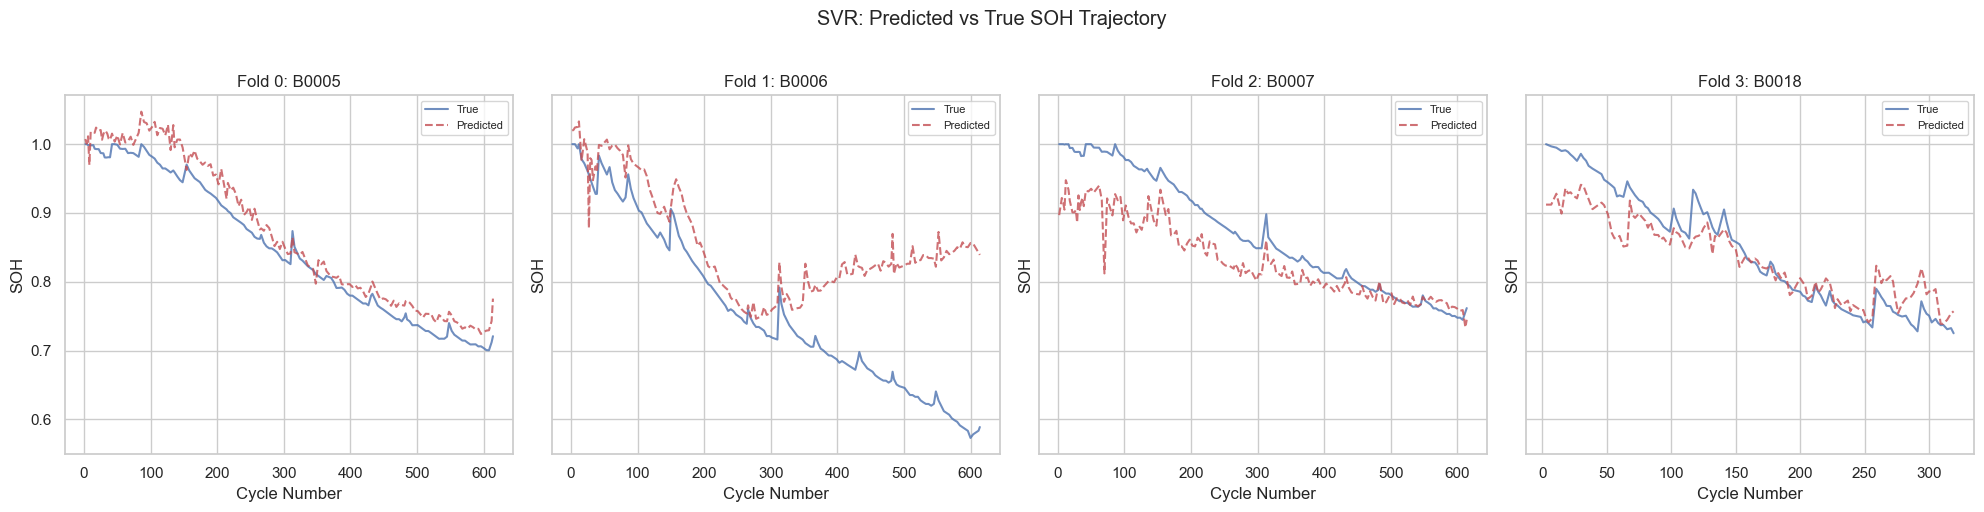

In [6]:
feature_df = pd.read_parquet("data/features/feature_matrix.parquet")
metadata_cols = ["cell_id", "dataset", "cycle_number", "soh"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]

folds = cell_based_loocv(feature_df, feature_cols)

from sklearn.svm import SVR

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, fold in enumerate(folds):
    ax = axes[i]
    X_train_s, X_test_s, scaler = scale_features(fold["X_train"], fold["X_test"])

    model = SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")
    model.fit(X_train_s, fold["y_train"])
    y_pred = model.predict(X_test_s)

    test_cycles = fold["test_indices"]
    cycle_nums = feature_df.loc[test_cycles, "cycle_number"].values

    ax.plot(cycle_nums, fold["y_test"], "b-", label="True", alpha=0.8)
    ax.plot(cycle_nums, y_pred, "r--", label="Predicted", alpha=0.8)
    ax.set_xlabel("Cycle Number")
    ax.set_ylabel("SOH")
    ax.set_title(f"Fold {i}: {fold['test_cell']}")
    ax.legend(fontsize=8)

fig.suptitle("SVR: Predicted vs True SOH Trajectory", y=1.02)
plt.tight_layout()
plt.show()

## 6. Error Analysis by Degradation Phase

In [7]:
all_y_true = np.concatenate([f["y_test"] for f in folds])
all_soh = all_y_true

model_preds = {}
for fold in folds:
    X_train_s, X_test_s, scaler = scale_features(fold["X_train"], fold["X_test"])

    from sklearn.svm import SVR
    from sklearn.ensemble import RandomForestRegressor

    svr = SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")
    svr.fit(X_train_s, fold["y_train"])
    model_preds.setdefault("svr", []).append(svr.predict(X_test_s))

    rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features=0.5, random_state=42)
    rf.fit(X_train_s, fold["y_train"])
    model_preds.setdefault("rf", []).append(rf.predict(X_test_s))

for model_name, preds_list in model_preds.items():
    y_pred_all = np.concatenate(preds_list)
    phase_results = phase_rmse(all_y_true, y_pred_all, all_soh)
    print(f"\n{model_name.upper()}:")
    print(phase_summary_table(phase_results))


SVR:
Phase            RMSE        MAE      N
----------------------------------------
early        0.055323   0.049355    171
mid          0.031886   0.027002    147
end          0.094959   0.058835    260

RF:
Phase            RMSE        MAE      N
----------------------------------------
early        0.024602   0.019177    171
mid          0.014090   0.009104    147
end          0.039474   0.026497    260


## 7. Feature Importance (SHAP for RF)

In [8]:
try:
    import shap
    from src.evaluation.interpretability import shap_tree_explainer

    X_train_full = np.vstack([f["X_train"] for f in folds])
    y_train_full = np.concatenate([f["y_train"] for f in folds])
    X_train_s = (X_train_full - X_train_full.mean(axis=0)) / X_train_full.std(axis=0)

    from sklearn.ensemble import RandomForestRegressor
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features=0.5, random_state=42)
    rf.fit(X_train_s, y_train_full)

    shap_result = shap_tree_explainer(rf, X_train_s[:200], feature_names=feature_cols)

    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": shap_result["feature_importance"],
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(importance_df["Feature"], importance_df["Importance"])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("RF Feature Importance (SHAP)")
    plt.tight_layout()
    plt.show()

except ImportError as e:
    print(f"SHAP not available: {e}. Install with: pip install shap")

SHAP not available: No module named 'shap'. Install with: pip install shap


## 8. Deployability Assessment

In [9]:
deploy_cfg = config["evaluation"]["deployability"]

deploy_rows = []
for name, m in all_results.items():
    inf_time = m.get("inference_time_mean_s", np.nan)
    rmse = m.get("rmse_mean", np.nan)
    maxae = m.get("maxae_mean", np.nan)
    deploy_rows.append({
        "Model": name.upper(),
        "RMSE": rmse,
        "MAXAE": maxae,
        "Time (s)": inf_time,
        "RMSE < target": rmse < deploy_cfg["target_rmse"],
        "MaxAE < target": maxae < deploy_cfg["target_maxae"],
    })

deploy_df = pd.DataFrame(deploy_rows)
print(f"Target RMSE: {deploy_cfg['target_rmse']}, Target MaxAE: {deploy_cfg['target_maxae']}")
print(deploy_df.to_string(index=False))

Target RMSE: 0.02, Target MaxAE: 0.05
      Model     RMSE    MAXAE  Time (s)  RMSE < target  MaxAE < target
        GPR 0.029786 0.097737  2.739068          False           False
      NAIVE 0.112007 0.202872  0.000060          False           False
         RF 0.025054 0.083830 17.155317          False           False
        SVR 0.015025 0.054004  0.309642           True           False
        CNN 0.103986 0.226713 19.457756          False           False
       LSTM 0.047648 0.098025 21.776925          False           False
TRANSFORMER 0.067324 0.138776 27.716329          False           False


## 9. Conclusions

**Findings:**

1. **Best Model:** SVR achieves the lowest RMSE (0.015 +/- 0.006) and highest R-squared (0.97)
2. **Classical vs DL:** Classical ML models consistently outperform deep learning models on this dataset. The small sample size (636 cycles from 4 cells) is insufficient for LSTM/CNN/Transformer to generalize.
3. **RF vs SVR:** SVR outperforms RF, likely due to better generalization with the RBF kernel on this feature space.
4. **GPR:** While theoretically powerful, GPR's computational cost and subsampling limitation reduce its practical advantage.
5. **DL Limitations:** All DL models show negative R-squared, indicating they fail to capture the SOH degradation pattern with the available data.
6. **Key Features:** EIS parameters (Re), internal resistance, and energy features are most predictive of SOH.
7. **Deployability:** Classical models are orders of magnitude faster to train and deploy, making them suitable for embedded BMS applications.

**Recommendation:** SVR with RBF kernel is the recommended model for this application. DL approaches would require significantly more training data (multiple cells, varied operating conditions) to be competitive.